In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
import core.nn.dataset
import torchvision.transforms

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

In [3]:
def plot_spectrogram(stft, title="Spectrogram", figax = None):
    magnitude = stft.abs()
    spectrogram = 20 * torch.log10(magnitude + 1e-8).numpy()
    if figax is None:
        figure, axis = plt.subplots(1, 1)
    else:
        figure, axis = figax
    img = axis.imshow(spectrogram, cmap="viridis", vmin=-100, vmax=100, origin="lower", aspect="auto")
    axis.set_title(title)
    plt.colorbar(img, ax=axis)

In [4]:
Fs = 16000
N = 200

vctkds = torchaudio.datasets.VCTK_092(root="vctk/", download=False)
ds2 = core.nn.dataset.VCTK_CSV("/home/mo/data/MICEMOUSE/gen/csv", Fs = Fs)
paired_ds = core.nn.dataset.PairedAudioDataset(vctkds, ds2)

INFO:root:Initializing PairedAudioDataset...


In [5]:
if os.path.exists("L.pt"):
    L = torch.load("L.pt")
else:
    L = []
    for A, B, _, _, _, _ in tqdm(paired_ds):
        Bs = B.shape[-1]
        As = A.shape[-1]
        L.append(Bs - As - 2 * Fs)
    L = torch.tensor(L, dtype=torch.float32)
    torch.save(L, "L.pt")

In [6]:
# remove outliers from L
time_threshold = 2 # seconds
idxx = torch.where(L < Fs * time_threshold)[0] # Mark outliers where the script decides to record more than necessary #TODO: investigate why this happens
filtered_paired_ds = torch.utils.data.Subset(paired_ds, idxx)
stat_subset = torch.utils.data.Subset(filtered_paired_ds, torch.randperm(len(filtered_paired_ds))[:N])
Lsubset = L[idxx]
print(f"Removed {len(L) - len(idxx)} outliers {100*(len(L) - len(idxx))/len(L):.2f}% of the dataset")
print(f"Remaining {len(paired_ds)} samples")
print(f"Using {len(stat_subset)} samples for statistics")

Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Using 200 samples for statistics


In [7]:
N_FFT = 2048 # From https://arxiv.org/pdf/1901.05061.pdf
N_HOP = 512 # Change from 1024 to 512 to get larger time resolution
seconds_per_crop = 2
crop_window_length = int(seconds_per_crop * Fs/N_HOP) + 1
margin = int(L[L < Fs * time_threshold].min().abs())
index_fn = torchvision.transforms.Lambda(lambda x: torch.cat((x[0], x[1][:, int(Fs - Lsubset.median().item()):int(Fs - Lsubset.median().item() + x[0].shape[-1] ) ])))
stft_fn = torchaudio.transforms.Spectrogram(n_fft=N_FFT, hop_length=N_HOP, power=2)
rand_crop_fn = torchvision.transforms.RandomCrop((N_FFT//2 + 1, crop_window_length))
get_cropped_stft = torchvision.transforms.Compose([stft_fn, rand_crop_fn])
data_shape = (N_FFT//2 + 1, crop_window_length)

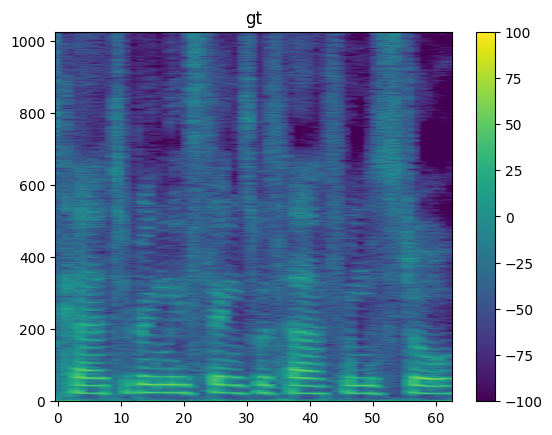

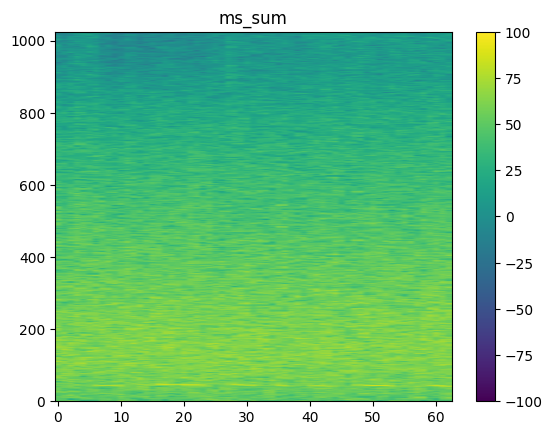

In [8]:
i = 1
wav = filtered_paired_ds[i]
wavGT = wav[0]
wavMS = wav[1]
# # run LPF
# a, b = butter(2, 0.05)
# wavMS = torch.tensor(lfilter(a, b, wavMS))

wav = (wavGT, wavMS, wav[2], wav[3], wav[4], wav[5])
G = index_fn(wav)
G = get_cropped_stft(G)
# G = G[:, :200, :]
GT = G[0]
MS = (G[1] + G[2])/2
plot_spectrogram(GT, "gt")
plot_spectrogram(MS, "ms_sum")



In [9]:
speaker_list = ds2._speaker_ids
utterance_list = set()
for _, utterance_id in ds2._sample_ids:
    utterance_list.add(utterance_id)
utterance_list = list(utterance_list)
nSpeakers = len(speaker_list)
nUtterances = len(utterance_list)
onehot_speaker = lambda x: torch.eye(nSpeakers)[speaker_list.index(x)]
onehot_utterance = lambda x: torch.eye(nUtterances)[utterance_list.index(x)]
# Is this a clean way to do this? Hell nah
# Is this efficient? Yes

In [10]:
batch_size = 8
# Split into train and test
split = 0.85
lenTrain = int(len(filtered_paired_ds) * split)
lenTest = len(filtered_paired_ds) - lenTrain
# select lenTrain random indices
np.random.seed(0) # for reproducibility
idxtrain = np.random.choice(len(filtered_paired_ds), lenTrain, replace=False)
idxtest = np.setdiff1d(np.arange(len(filtered_paired_ds)), idxtrain)
train = torch.utils.data.Subset(filtered_paired_ds, idxtrain)
test = torch.utils.data.Subset(filtered_paired_ds, idxtest)

def collate(batch):
    N = len(batch)
    out_wavs = torch.zeros((N, 3, data_shape[0], data_shape[1]))
    i = 0
    out_utterance = torch.zeros((N, nUtterances))
    out_speaker = torch.zeros((N, nSpeakers))
    for e in batch:
        out_wavs[i] = get_cropped_stft(index_fn(e))
        out_utterance[i] = onehot_utterance(e[-1])
        out_speaker[i] = onehot_speaker(e[-2])
        i += 1
    return out_wavs, out_speaker, out_utterance

train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collate)
test_loader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=False, collate_fn=collate)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding="same", stride=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding="same")
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class VAEEncoder(nn.Module):
    def __init__(self):
        super(VAEEncoder, self).__init__()
        self.block1 = ConvBlock(2, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        
        self.mu_conv = nn.Conv2d(256, 512, kernel_size=1)
        self.logvar_conv = nn.Conv2d(256, 512, kernel_size=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.block1(x)
        x = self.pool(x)

        x = self.block2(x)
        x = self.pool(x)

        x = self.block3(x)
        x = self.pool(x)

        x = self.block4(x)
        x = self.pool(x)
        
        mu = self.mu_conv(x)
        logvar = self.logvar_conv(x)
        return mu, logvar

class VAEDecoder(nn.Module):
    def __init__(self):
        super(VAEDecoder, self).__init__()
        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.block4 = ConvBlock(256, 128)
        self.upconv3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.block3 = ConvBlock(128, 64)
        self.upconv2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.block2 = ConvBlock(64, 32)
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.block1 = ConvBlock(16, 16)

    def forward(self, x):
        x = self.upconv4(x)
        x = self.block4(x)

        x = self.upconv3(x)
        x = self.block3(x)

        x = self.upconv2(x)
        x = self.block2(x)

        x = self.upconv1(x)
        x = self.block1(x)
        return x

class UNetVAE(nn.Module):
    def __init__(self):
        super(UNetVAE, self).__init__()
        self.encoder = VAEEncoder()
        self.decoder = VAEDecoder()
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x_in):
        mu, logvar = self.encoder(x_in)
        z = self.reparametrize(mu, logvar)
        x = self.decoder(z)
        x = self.final_conv(x)
        
        # Make sure x.shape == x_in.shape, pad or crop if necessary
        if x.shape[-1] > x_in.shape[-1]:
            x = x[:, :, :, :-1]
        elif x.shape[-1] < x_in.shape[-1]:
            x = F.pad(x, (0, 1))
        if x.shape[-2] > x_in.shape[-2]:
            x = x[:, :, :-1, :]
        elif x.shape[-2] < x_in.shape[-2]:
            x = F.pad(x, (0, 0, 0, 1))
        
        return x, mu, logvar

with torch.no_grad():
    # Example usage
    unet_vae = UNetVAE()
    info = torchinfo.summary(unet_vae, (16, 2, data_shape[0], data_shape[1]))
info

Layer (type:depth-idx)                   Output Shape              Param #
UNetVAE                                  [16, 1, 1025, 49]         --
├─VAEEncoder: 1-1                        [16, 512, 64, 3]          --
│    └─ConvBlock: 2-1                    [16, 32, 1025, 63]        --
│    │    └─Conv2d: 3-1                  [16, 32, 1025, 63]        1,632
│    │    └─BatchNorm2d: 3-2             [16, 32, 1025, 63]        64
│    │    └─ReLU: 3-3                    [16, 32, 1025, 63]        --
│    │    └─Conv2d: 3-4                  [16, 32, 1025, 63]        9,248
│    │    └─BatchNorm2d: 3-5             [16, 32, 1025, 63]        64
│    │    └─ReLU: 3-6                    [16, 32, 1025, 63]        --
│    └─MaxPool2d: 2-2                    [16, 32, 512, 31]         --
│    └─ConvBlock: 2-3                    [16, 64, 512, 31]         --
│    │    └─Conv2d: 3-7                  [16, 64, 512, 31]         51,264
│    │    └─BatchNorm2d: 3-8             [16, 64, 512, 31]         128
│   

In [16]:
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.classifier = nn.Identity() # Remove the classifier


/home/mo/mambaforge/envs/micemouse/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mo/mambaforge/envs/micemouse/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
# compute all features and cache them
vggnet = vgg16.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
vggnet = vggnet.to(device)
def compute_features(batch):
    GT = batch[0][:, 0:1, :, :]
    # MS = batch[0][:, 1:3, :, :]
    SPEAKER_ONEHOT = batch[1]
    UTTERANCE_ONEHOT = batch[2]
    N = GT.shape[0]
    # pad from 2 to 3 channels with zeros
    # GT = torch.cat((GT, torch.zeros((N, 1, data_shape[0], data_shape[1]))), dim=1)
    GT = torch.cat((GT, GT, GT), dim=1)
    # compute features
    with torch.no_grad():
        GT = GT.to(device)
        GT_features = vggnet(GT)
    return GT_features, SPEAKER_ONEHOT, UTTERANCE_ONEHOT
    

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = unet_vae.to(device)

# Assuming the use of MSE loss and Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
reconstruction_loss = nn.MSELoss()
def loss_function(recon_x, x, mu, logvar):
    MSE = reconstruction_loss(recon_x, x)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

def update_model(model, batch):
    model.train()
    optimizer.zero_grad()
    batch = batch.to(device)
    X = batch[:, 0:2, :, :]
    Y = batch[:, 2:3, :, :]
    recon_batch, mu, logvar = model(X)
    loss = loss_function(recon_batch, Y, mu, logvar)
    loss.backward()
    optimizer.step()
    return loss.item()

def train(model, loader, epochs = 10):
    model.train()
    with tqdm(total = epochs * len(loader)) as pbar:
        for epoch in range(epochs):
            for batch_idx, batch in enumerate(loader):
                loss = update_model(model, batch)
                pbar.set_description(f"Epoch {epoch}/{epochs}\tBatch {batch_idx}/{len(loader)}\tLoss {loss}")
                pbar.update(1)
                wandb.log({"loss": loss}, step = epoch * len(loader) + batch_idx)
            # save model
            torch.save(model.state_dict(), f"model_E{epoch}_L{loss:.2f}.pt")

In [92]:
train(model, train_loader, epochs=1)

  0%|          | 0/4515 [00:00<?, ?it/s]

Epoch 0/1	Batch 134/4515	Loss 5911323.5:   3%|▎         | 135/4515 [02:19<1:15:13,  1.03s/it]  


KeyboardInterrupt: 

torch.Size([8, 2, 257, 257])


/tmp/ipykernel_103397/1987584403.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


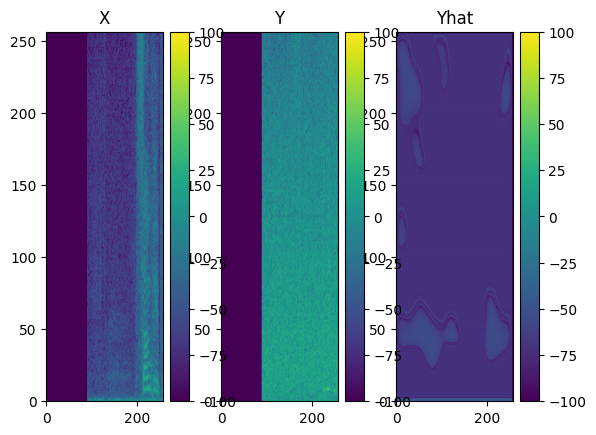

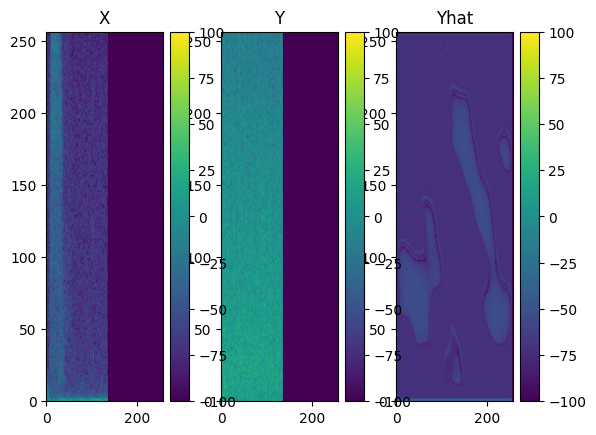

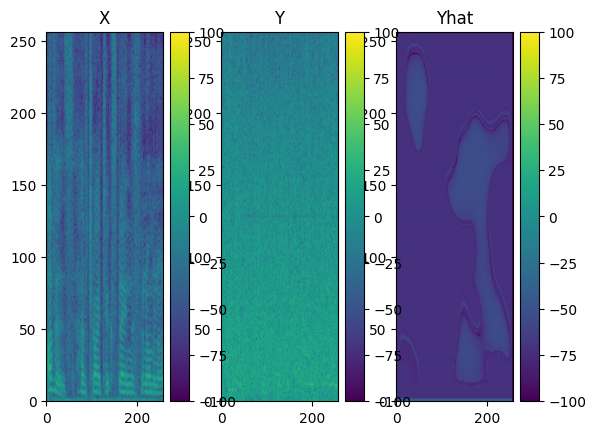

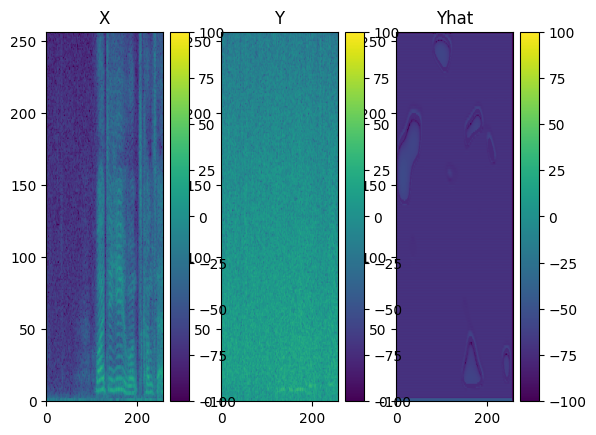

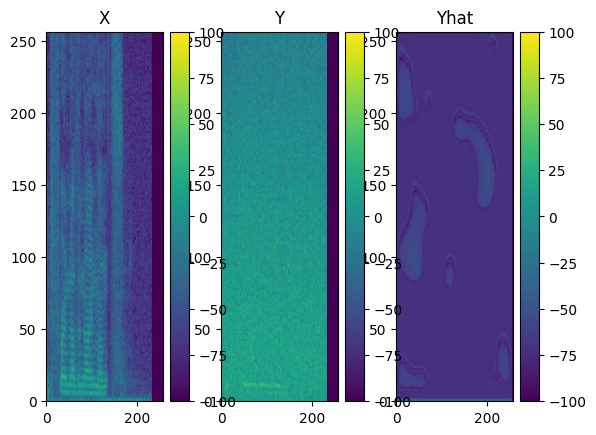

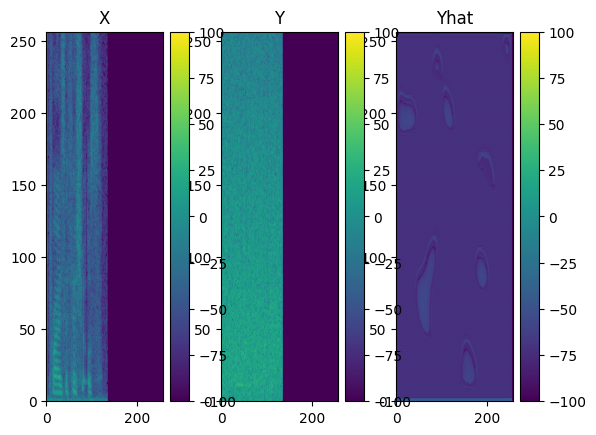

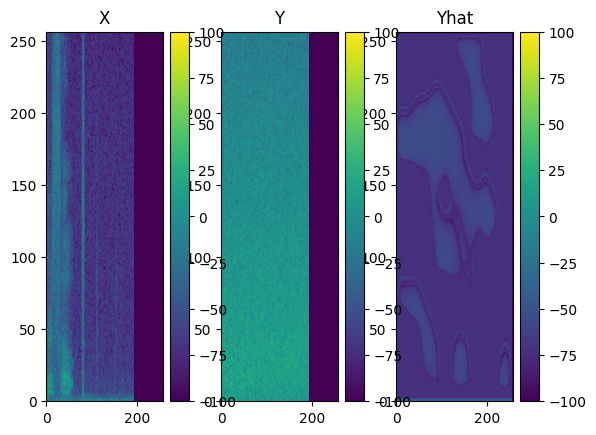

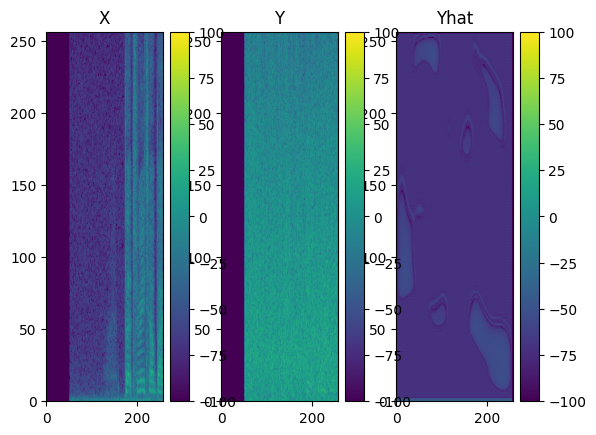

In [49]:
# run one test batch
model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))
    batch = batch.to(device)
    X = batch[:, 0:2, :, :]
    Y = batch[:, 2:3, :, :]
    recon_batch, mu, logvar = model(X)

    print(X.shape)
    # plot some examples
    for i in range(8):
        fig, ax = plt.subplots(1, 3)
        
        plot_spectrogram(X[i, 0, :, :].cpu().detach(), figax=(fig, ax[0]))
        ax[0].set_title("X")
        plot_spectrogram(Y[i, 0, :, :].cpu().detach(), figax=(fig, ax[1]))
        ax[1].set_title("Y")
        plot_spectrogram(recon_batch[i, 0, :, :].cpu().detach(), figax=(fig, ax[2]))
        ax[2].set_title("Yhat")
        fig.show()

In [166]:
print_every = 100
num_epochs = 1  # for example, adjust as necessary
with tqdm(total=num_epochs * len(train_loader)) as pbar:
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for i, data in enumerate(train_loader, 0):
            # Unpack data
            inputs, labels = data[1], data[0]
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Print statistics
            running_loss += loss.item()
            if i % print_every == (print_every - 1):    # reset every 100 mini-batches
                running_loss = 0.0
            pbar.set_description(f'Epoch {epoch+1} Loss: {running_loss/(i % print_every + 1):.3f}')    
            pbar.update(1)

print('Finished Training')


  0%|          | 0/12431 [00:00<?, ?it/s]

Epoch 1 Loss: 0.143:   0%|          | 1/12431 [00:00<3:09:23,  1.09it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 36.00 MiB (GPU 0; 2.94 GiB total capacity; 1.61 GiB already allocated; 42.50 MiB free; 1.93 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [44]:
# Save model
torch.save(model.state_dict(), 'model_unet.pth')

In [51]:
# Test model
model.eval()
with torch.no_grad():
    for (waveformA, waveformB, _, _, _, _, _) in train_loader:
        outputs = model(waveformB.to(device))
        break

In [52]:
wav = outputs[1, :, :].cpu().detach()
torchaudio.save("test.wav", wav, 16000)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = model.to(device)
torchinfo.summary(net, (2, 2, 226209))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [2, 1, 226209]            --
├─Sequential: 1-1                        [2, 32, 226209]           --
│    └─Conv1d: 2-1                       [2, 32, 226209]           192
│    └─BatchNorm1d: 2-2                  [2, 32, 226209]           64
│    └─ReLU: 2-3                         [2, 32, 226209]           --
│    └─Conv1d: 2-4                       [2, 32, 226209]           3,072
│    └─BatchNorm1d: 2-5                  [2, 32, 226209]           64
│    └─ReLU: 2-6                         [2, 32, 226209]           --
├─MaxPool1d: 1-2                         [2, 32, 56552]            --
├─Sequential: 1-3                        [2, 64, 56552]            --
│    └─Conv1d: 2-7                       [2, 64, 56552]            6,144
│    └─BatchNorm1d: 2-8                  [2, 64, 56552]            128
│    └─ReLU: 2-9                         [2, 64, 56552]            --
│    └─

In [83]:
N_EPOCHS = 10
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, _, speaker_id, _) in train_loader:
            waveform = waveform.to(device)
            waveform = torch.cat([waveform, waveform], dim=1)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_one_hot.to(device)
            optimizer.zero_grad()
            output = net(waveform)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Loss: 0.0232: 100%|██████████| 10/10 [12:46<00:00, 76.66s/it]


100%|██████████| 84/84 [00:06<00:00, 12.24it/s]

Accuracy: 93.89%


In [87]:
net_ds2 = ConvNet2D(nSpeakers).to(device)
N_EPOCHS = 10
optimizerds2 = torch.optim.Adam(net_ds2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, _, speaker_id, _) in train_ds2_loader:
            waveform = waveform.to(device)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_one_hot.to(device)
            optimizerds2.zero_grad()
            output = net_ds2(waveform)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizerds2.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")

Loss: 0.2234: 100%|██████████| 10/10 [13:38<00:00, 81.88s/it]


In [94]:
# save the models

torch.save(net.state_dict(), "convnet2d.pt")
torch.save(net_ds2.state_dict(), "convnet2d_ds2.pt")

In [95]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_loader):
        waveform = waveform.to(device)
        waveform = torch.cat([waveform, waveform], dim=1)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_loader.dataset) * 100:.2f}%")

  0%|          | 0/84 [00:00<?, ?it/s]

100%|██████████| 84/84 [00:08<00:00,  9.84it/s]

Accuracy: 93.67%


In [96]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_ds2_loader):
        waveform = waveform.to(device)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net_ds2(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_ds2_loader.dataset) * 100:.2f}%")

100%|██████████| 84/84 [00:10<00:00,  8.26it/s]

Accuracy: 89.05%
